<a href="https://colab.research.google.com/github/Kazureee/Machine-Learning-Lesson/blob/main/Hierarchical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
from matplotlib import pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [51]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/iris_cluster.csv')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,cluster
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1


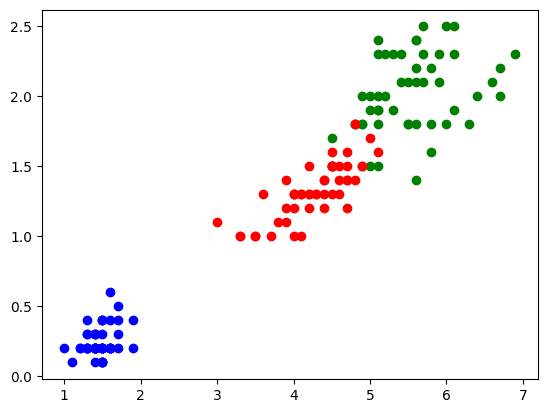

In [52]:
df1 = df[df.cluster == 0]
df2 = df[df.cluster == 1]
df3 = df[df.cluster == 2]

plt.scatter(df1.petal_length, df1.petal_width, color='green')
plt.scatter(df2.petal_length, df2.petal_width, color='blue')
plt.scatter(df3.petal_length, df3.petal_width, color='red')

In [ ]:
from sklearn.model_selection import train_test_split
y = df.cluster
x = df.drop(['cluster', 'species'], axis='columns')

#partition data(Training dataset (80), testing dataset (20))
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

x_test

In [54]:
#K Means Clustering (Training)
from sklearn.cluster import KMeans
km = KMeans(n_clusters=3)
km.fit_predict(x_train, y_train)

array([0, 2, 2, 2, 0, 0, 2, 1, 0, 1, 0, 1, 2, 1, 2, 0, 0, 1, 1, 2, 1, 1,
       2, 2, 2, 1, 1, 0, 2, 0, 1, 2, 1, 2, 2, 2, 1, 2, 0, 0, 1, 1, 1, 2,
       2, 2, 2, 0, 1, 0, 2, 0, 2, 2, 1, 0, 2, 2, 0, 1, 2, 2, 0, 0, 1, 2,
       0, 2, 0, 1, 0, 1, 0, 2, 1, 2, 2, 0, 0, 2, 2, 1, 0, 0, 2, 2, 0, 2,
       0, 0, 2, 2, 2, 0, 2, 1, 1, 0, 1, 1, 0, 2, 1, 0, 0, 2, 2, 0, 1, 2,
       2, 2, 0, 0, 1, 1, 0, 2, 0, 0], dtype=int32)

In [55]:
#K Means prediction (Testing)
y_km_predicted = km.fit_predict(x_test)
y_km_predicted

array([0, 1, 0, 2, 1, 0, 1, 2, 1, 2, 2, 1, 2, 1, 1, 0, 1, 1, 0, 1, 0, 2,
       2, 2, 1, 0, 0, 2, 0, 0], dtype=int32)

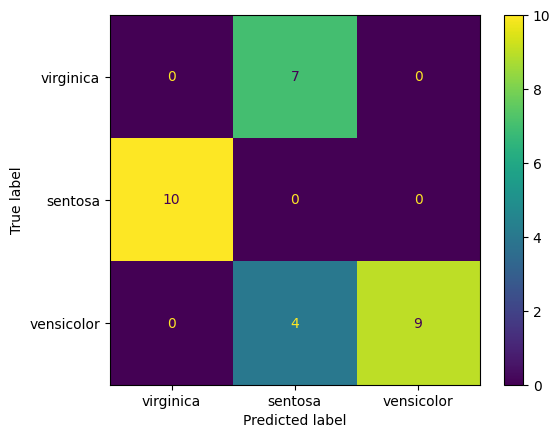

In [56]:
#Confusion Matrix (K Means) (Evalution)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_km_predicted)
cm

cm_display = ConfusionMatrixDisplay(cm, display_labels=['virginica', 'sentosa', 'vensicolor'])
cm_display.plot()
plt.show()

In [86]:
#DBSCAN (Training)
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan.fit_predict(x_train, y_train)

array([ 0,  1,  1,  1,  0,  0,  1,  2,  0,  2,  0, -1,  1,  2,  1,  0,  0,
        2,  2,  1,  2,  2,  1, -1,  1,  2, -1,  0,  1,  0,  2, -1, -1,  1,
        1,  1,  2,  1,  0,  0, -1, -1,  2,  1,  1,  1,  1,  0,  2,  0,  1,
        0,  1,  1,  2,  0,  1, -1,  0, -1,  1,  1,  0,  0,  2,  1,  0,  1,
        0, -1,  0,  2,  0,  1, -1,  1,  1,  0,  0,  1,  1, -1,  0,  0,  1,
        1,  0, -1,  0,  0,  1,  1,  1,  0,  1,  2,  1,  0,  2, -1,  0, -1,
       -1,  0,  0,  1,  1,  0,  2,  1,  1,  1,  0,  0, -1,  2,  0,  1,  0,
        0])

In [87]:
#DBSCAN prediction (Testing)
y_dbscan_predicted = dbscan.fit_predict(x_test)
y_dbscan_predicted

array([-1, -1, -1,  0, -1, -1, -1,  0, -1,  0,  0, -1,  0, -1, -1, -1, -1,
       -1, -1, -1, -1, -1,  0,  0, -1, -1, -1, -1, -1, -1])

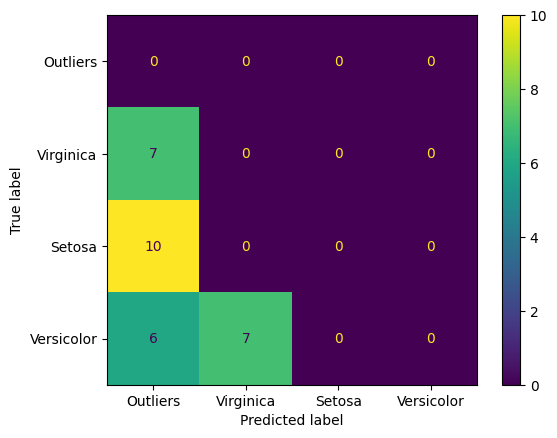

In [90]:
#Confusion Matrix (DBSCAN) (Evalution)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_dbscan_predicted)
cm

cm_display = ConfusionMatrixDisplay(cm, display_labels=['Outliers', 'Virginica', 'Setosa', 'Versicolor'])
cm_display.plot()
plt.show()

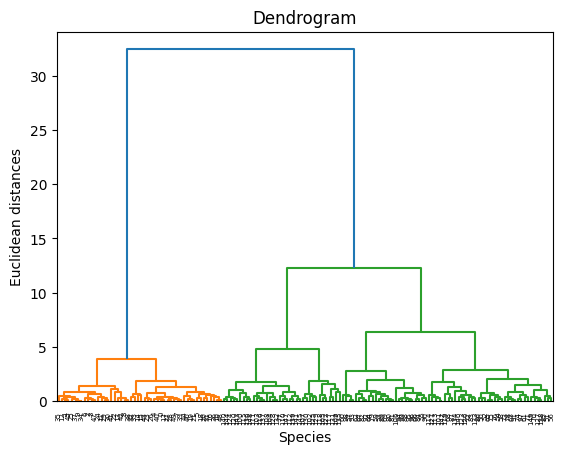

In [92]:
#Hierarchical Cluster
#Visualization
import scipy.cluster.hierarchy as sch
dendrogam = sch.dendrogram(sch.linkage(x, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Species')
plt.ylabel('Euclidean distances')
plt.show()

In [95]:
#training
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
hc.fit_predict(x_train, y_train)

array([1, 0, 0, 0, 1, 1, 0, 2, 1, 2, 1, 2, 0, 2, 0, 1, 1, 2, 2, 0, 2, 2,
       0, 0, 0, 2, 2, 1, 0, 1, 2, 0, 2, 0, 0, 0, 2, 0, 1, 1, 2, 2, 2, 0,
       0, 0, 0, 1, 2, 1, 0, 1, 0, 0, 2, 1, 0, 0, 1, 2, 0, 0, 1, 1, 2, 0,
       1, 0, 1, 2, 1, 2, 1, 0, 2, 0, 0, 1, 1, 0, 0, 2, 1, 1, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 0, 2, 0, 1, 2, 2, 1, 0, 2, 1, 1, 0, 0, 1, 2, 0,
       0, 0, 1, 1, 2, 2, 1, 0, 1, 1])

In [97]:
#Testing
y_hc_predicted = hc.fit_predict(x_test)
y_hc_predicted

array([1, 0, 1, 2, 0, 1, 0, 2, 0, 2, 2, 0, 2, 0, 0, 1, 0, 0, 1, 0, 1, 2,
       2, 2, 0, 1, 1, 2, 1, 1])

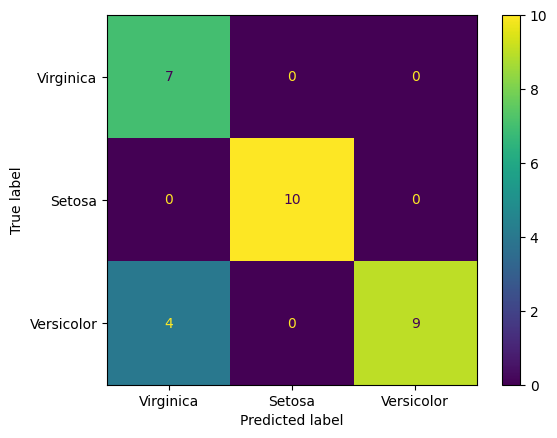

In [103]:
#Confusion Matrix (DBSCAN) (Evalution)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_hc_predicted)
cm

cm_display = ConfusionMatrixDisplay(cm, display_labels=['Virginica', 'Setosa', 'Versicolor'])
cm_display.plot()
plt.show()